In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


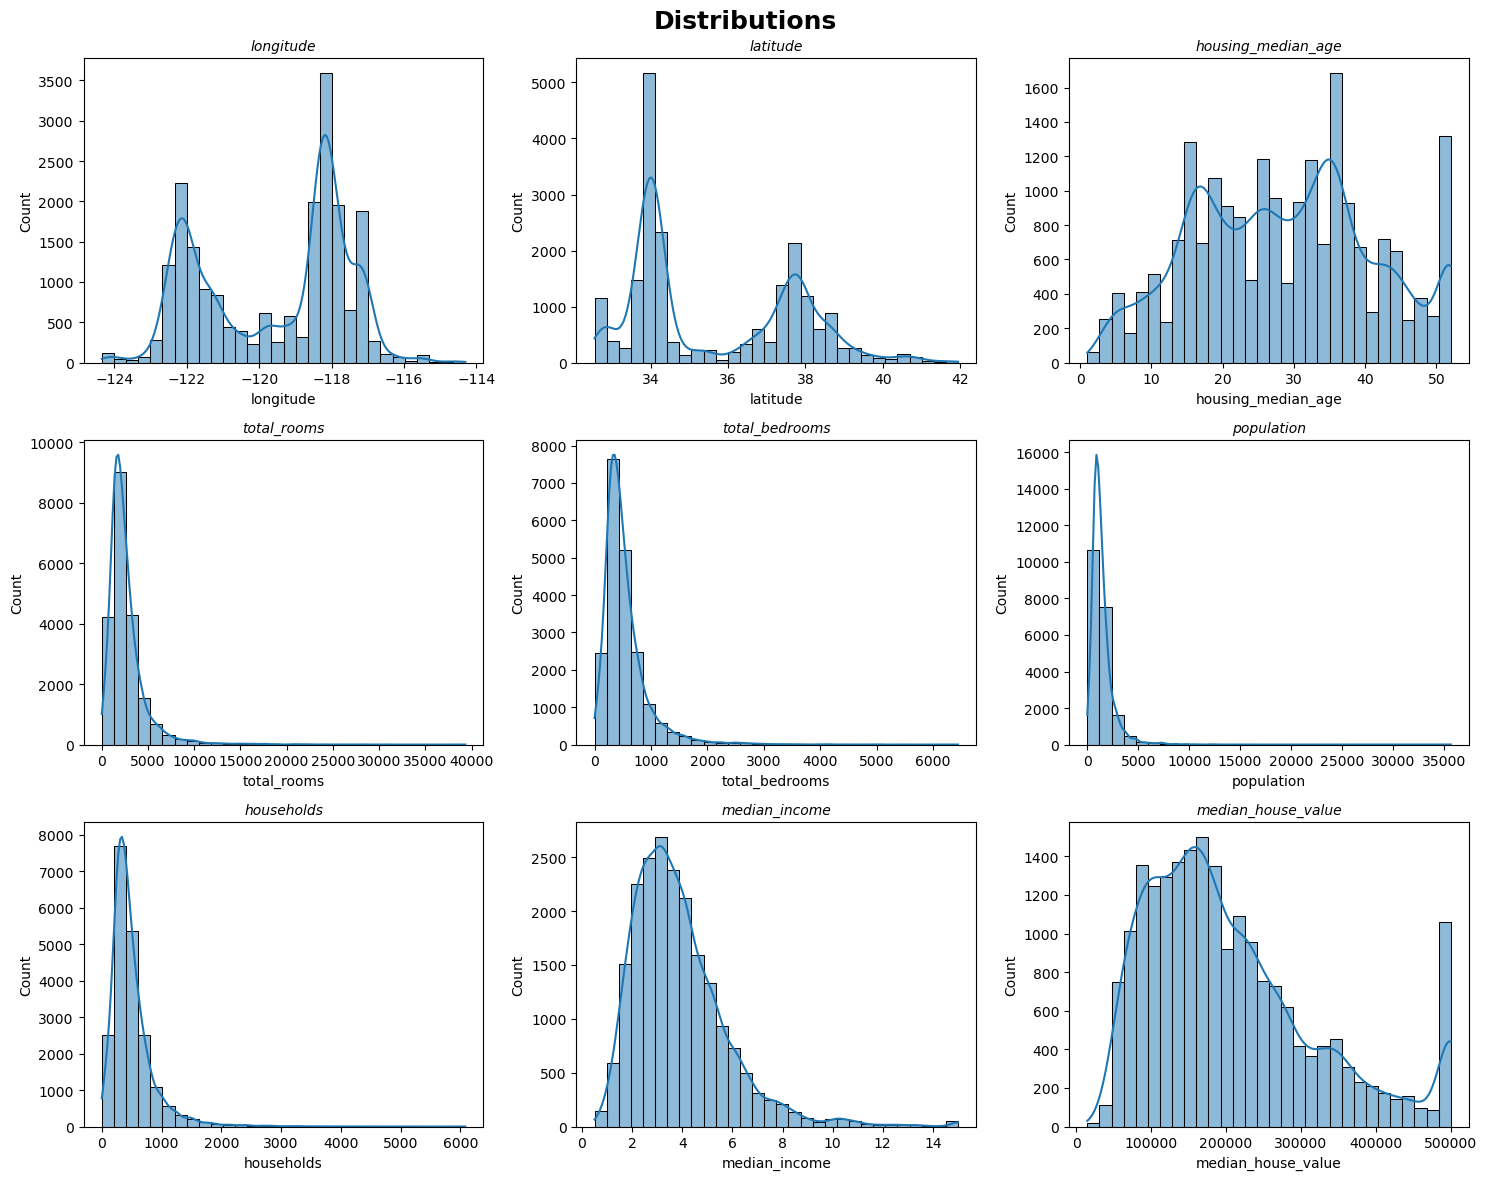

In [6]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))
fig.suptitle("Distributions", fontsize = 18, fontweight = 'bold')

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(data = df, x = col, kde=True, ax=ax, bins=30)
    ax.set_title(col, fontsize=10, fontstyle="italic")


plt.tight_layout()
plt.show()

In [7]:
# filling NaN value with median
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [8]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

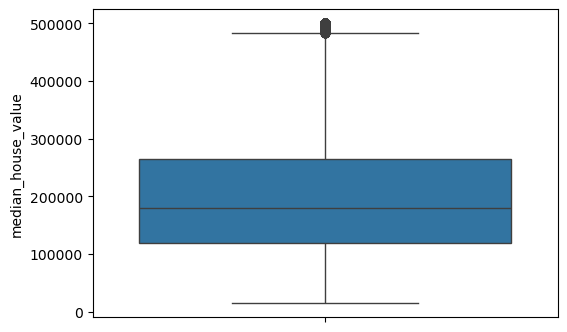

In [9]:
# outlier data - target 

plt.figure(figsize=(6,4))
sns.boxplot(data = df, y = "median_house_value")
plt.show()

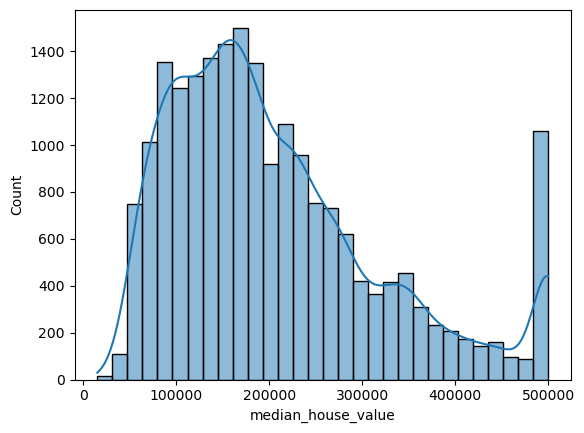

In [10]:
sns.histplot(df["median_house_value"], bins=30, kde = True) # I will transformation with box-cox 
plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [13]:
# one-hot encoding --> ocean_proximity

df = pd.get_dummies(df, columns=["ocean_proximity"])

df["ocean_proximity_NEAR OCEAN"] = df["ocean_proximity_NEAR OCEAN"].astype(int)
df["ocean_proximity_NEAR BAY"] = df["ocean_proximity_NEAR BAY"].astype(int)
df["ocean_proximity_ISLAND"] = df["ocean_proximity_ISLAND"].astype(int)
df["ocean_proximity_INLAND"] = df["ocean_proximity_INLAND"].astype(int)
df["ocean_proximity_<1H OCEAN"] = df["ocean_proximity_<1H OCEAN"].astype(int)

In [14]:
df.head(6)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0,0,0,1,0


In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("median_house_value", axis = 1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [16]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
3551,-118.66,34.23,18.0,897.0,142.0,263.0,110.0,6.1288,1,0,0,0,0
12693,-121.41,38.57,16.0,4429.0,1124.0,1538.0,960.0,3.2443,0,1,0,0,0
18943,-122.04,38.28,12.0,3861.0,795.0,2129.0,806.0,3.6760,0,1,0,0,0
11850,-121.14,39.86,16.0,2534.0,557.0,638.0,244.0,2.2101,0,1,0,0,0
12643,-121.46,38.53,37.0,2745.0,588.0,1607.0,556.0,1.8007,0,1,0,0,0


In [17]:
from sklearn.preprocessing import PowerTransformer

pt_X = PowerTransformer(method="yeo-johnson")

X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [18]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 
          'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=columns)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=columns)

In [19]:
X_train_transformed_df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14443,-7.216450e-16,1.114782,1.119140,-1.007000,-1.078167,-1.149793,-1.173937,-0.572532,-0.887636,1.461306,-0.018606,-0.353264,-0.384988
14444,1.887379e-15,-1.632457,-0.994540,-0.859240,-1.102590,-1.176003,-1.088203,1.280032,-0.887636,1.461306,-0.018606,-0.353264,-0.384988
14445,5.273559e-16,-0.846440,0.147843,0.041350,0.306998,-0.205976,0.397916,0.056970,-0.887636,-0.684319,-0.018606,-0.353264,2.597483
14446,8.326673e-17,-0.559087,0.378002,0.176498,-0.251296,-0.179182,-0.214564,0.666439,-0.887636,-0.684319,-0.018606,-0.353264,2.597483
14447,4.996004e-16,-0.833166,-0.326049,2.377092,1.802362,2.286215,1.950416,1.013919,1.126588,-0.684319,-0.018606,-0.353264,-0.384988


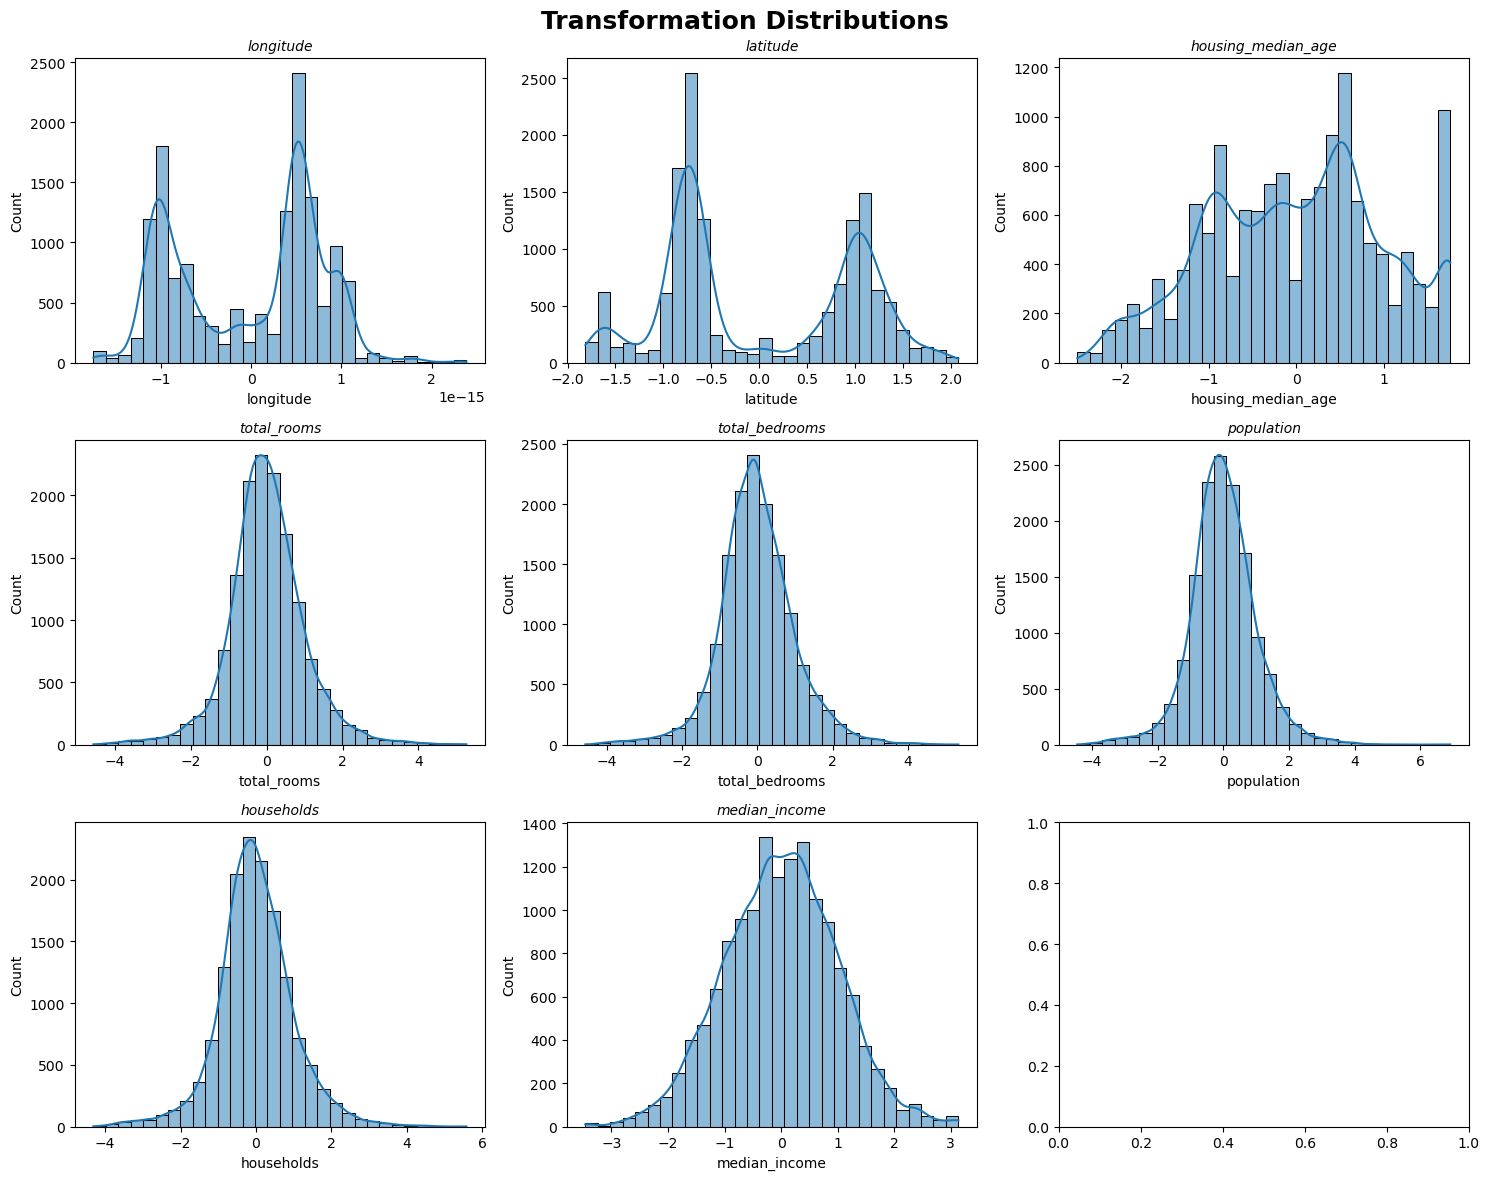

In [20]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))
fig.suptitle("Transformation Distributions", fontsize = 18, fontweight = 'bold')

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(data = X_train_transformed_df, x = col, kde=True, ax=ax, bins=30)
    ax.set_title(col, fontsize=10, fontstyle="italic")


plt.tight_layout()
plt.show()

In [21]:
# Target value transformation

from scipy.stats import boxcox

y_train_transformed, lambda_y = boxcox(y_train)

In [22]:
y_train_transformed

array([30.98788185, 28.1703542 , 26.65912795, ..., 30.94783563,
       29.53749393, 28.32726095], shape=(14448,))

In [23]:
lambda_y

np.float64(0.12313134801578143)

In [24]:
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [25]:
from xgboost import XGBRegressor

model = XGBRegressor()

In [26]:
model.fit(X_train_transformed, y_train_transformed)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
y_pred_transformed = model.predict(X_test_transformed)

y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [28]:
from sklearn.metrics import r2_score

print("Score: ", r2_score(y_test, y_pred_original))

Score:  0.8160108286138659


In [29]:
X_train.columns = X_train.columns.str.replace('<', 'less_than_', regex=False)
X_test.columns = X_test.columns.str.replace('<', 'less_than_', regex=False)

In [30]:
model = XGBRegressor()

In [31]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Score: ", r2_score(y_test, y_pred))

Score:  0.8319950178845702


In [32]:
# Bu tür dönüşümleri (Box-Cox, Yeo-Johnson) doğrusal modellerde sıklıkla büyük fark yaratır,
# ama ağaç tabanlı modellerde (XGBoost, Random Forest, LightGBM) genellikle etkisi sınırlıdır.

In [33]:
# Lineer Regresyon
from sklearn.linear_model import LinearRegression
 
regressor1 = LinearRegression()

regressor1.fit(X_train_transformed, y_train_transformed)

LinearRegression()

In [34]:
y_pred_transformed = regressor1.predict(X_test_transformed)

print("(Yanlış Kullanım!) Score: ", r2_score(y_test, y_pred_transformed))

(Yanlış Kullanım!) Score:  -3.218553125690553


In [35]:
# Doğru kullanım: 
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

print("Score: ", r2_score(y_test, y_pred_original))

Score:  0.6553105244999531


In [36]:
# Lineer Regresyon - Transformation Yok

regressor2 = LinearRegression()
regressor2.fit(X_train, y_train)
y_pred = regressor2.predict(X_test)

print("Score: ", r2_score(y_test, y_pred))

Score:  0.6413418707574335
